# Multi-Category and Robustness Evaluation

This notebook evaluates the pretrained feature-based anomaly-detection approach across **all 15 MVTec AD categories**.

The main evaluation uses every category:

- bottle, cable, capsule, carpet, grid,
- hazelnut, leather, metal_nut, pill, screw,
- tile, toothbrush, transistor, wood, zipper.

The objectives are to:

- verify the dataset structure for every category,
- build category-specific normal feature memory banks,
- calculate image-level and pixel-level anomaly metrics,
- compare performance across object and texture categories,
- save a reusable detector configuration for every category,
- evaluate robustness on a representative subset of categories.

Robustness testing is intentionally kept to representative categories only (`bottle`, `cable`, and `carpet`) so that the notebook stays practical to run on a GTX 1050.


In [1]:
from pathlib import Path
import os
import random
import sys

import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path(r"D:\PROJECTS\ANOMALY DETECTION")
DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "mvtec_ad"

TORCH_CACHE = PROJECT_ROOT / "models" / "torch_cache"
TORCH_CACHE.mkdir(parents=True, exist_ok=True)
os.environ["TORCH_HOME"] = str(TORCH_CACHE)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.mvtec_dataset import MVTecDataset
from src.models.resnet_feature_extractor import (
    ResNet18PatchExtractor,
)

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)
print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Project root: D:\PROJECTS\ANOMALY DETECTION
Dataset root: D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad
Device: cuda
GPU: NVIDIA GeForce GTX 1050


In [2]:
CATEGORIES = [
    "bottle",
    "cable",
    "capsule",
    "carpet",
    "grid",
    "hazelnut",
    "leather",
    "metal_nut",
    "pill",
    "screw",
    "tile",
    "toothbrush",
    "transistor",
    "wood",
    "zipper",
]

IMAGE_SIZE = 256
BATCH_SIZE = 8
VALIDATION_RATIO = 0.20

print("Selected categories:")

for category in CATEGORIES:
    print("-", category)

print("\nTotal categories:", len(CATEGORIES))
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Validation ratio:", VALIDATION_RATIO)


Selected categories:
- bottle
- cable
- capsule
- carpet
- grid
- hazelnut
- leather
- metal_nut
- pill
- screw
- tile
- toothbrush
- transistor
- wood
- zipper

Total categories: 15
Image size: 256
Batch size: 8
Validation ratio: 0.2


In [3]:
IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
}


def count_images(directory: Path) -> int:
    """Count all image files below a directory."""
    return sum(
        1
        for path in directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    )


category_records = []

for category in CATEGORIES:
    category_path = DATASET_ROOT / category

    train_path = category_path / "train"
    test_path = category_path / "test"
    ground_truth_path = category_path / "ground_truth"

    train_count = count_images(train_path)
    test_count = count_images(test_path)
    mask_count = count_images(ground_truth_path)

    test_defect_types = sorted(
        directory.name
        for directory in test_path.iterdir()
        if directory.is_dir()
    )

    category_records.append(
        {
            "category": category,
            "training_images": train_count,
            "test_images": test_count,
            "ground_truth_masks": mask_count,
            "test_defect_types": ", ".join(
                test_defect_types
            ),
        }
    )

category_summary_df = pd.DataFrame(
    category_records
)

category_summary_df

,category,training_images,test_images,ground_truth_masks,test_defect_types
0,bottle,209,83,63,"broken_large, broken_small, contamination, good"
1,cable,224,150,92,"bent_wire, cable_swap, combined, cut_inner_ins..."
2,capsule,219,132,109,"crack, faulty_imprint, good, poke, scratch, sq..."
3,carpet,280,117,89,"color, cut, good, hole, metal_contamination, t..."
4,grid,264,78,57,"bent, broken, glue, good, metal_contamination,..."
5,hazelnut,391,110,70,"crack, cut, good, hole, print"
6,leather,245,124,92,"color, cut, fold, glue, good, poke"
7,metal_nut,220,115,93,"bent, color, flip, good, scratch"
8,pill,267,167,141,"color, combined, contamination, crack, faulty_..."
9,screw,320,160,119,"good, manipulated_front, scratch_head, scratch..."


In [4]:
dataset_verification_records = []

for category in CATEGORIES:
    training_dataset = MVTecDataset(
        dataset_root=DATASET_ROOT,
        category=category,
        split="train",
        image_size=IMAGE_SIZE,
    )

    testing_dataset = MVTecDataset(
        dataset_root=DATASET_ROOT,
        category=category,
        split="test",
        image_size=IMAGE_SIZE,
    )

    training_sample = training_dataset[0]
    testing_sample = testing_dataset[0]

    dataset_verification_records.append(
        {
            "category": category,
            "training_samples": len(training_dataset),
            "testing_samples": len(testing_dataset),
            "training_image_shape": tuple(
                training_sample["image"].shape
            ),
            "testing_image_shape": tuple(
                testing_sample["image"].shape
            ),
            "training_label": int(
                training_sample["label"].item()
            ),
        }
    )

dataset_verification_df = pd.DataFrame(
    dataset_verification_records
)

dataset_verification_df

,category,training_samples,testing_samples,training_image_shape,testing_image_shape,training_label
0,bottle,209,83,"(3, 256, 256)","(3, 256, 256)",0
1,cable,224,150,"(3, 256, 256)","(3, 256, 256)",0
2,capsule,219,132,"(3, 256, 256)","(3, 256, 256)",0
3,carpet,280,117,"(3, 256, 256)","(3, 256, 256)",0
4,grid,264,78,"(3, 256, 256)","(3, 256, 256)",0
5,hazelnut,391,110,"(3, 256, 256)","(3, 256, 256)",0
6,leather,245,124,"(3, 256, 256)","(3, 256, 256)",0
7,metal_nut,220,115,"(3, 256, 256)","(3, 256, 256)",0
8,pill,267,167,"(3, 256, 256)","(3, 256, 256)",0
9,screw,320,160,"(3, 256, 256)","(3, 256, 256)",0


In [5]:
import time

import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from tqdm.auto import tqdm

d:\PROJECTS\ANOMALY DETECTION\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
feature_extractor = ResNet18PatchExtractor().to(
    DEVICE
)

feature_extractor.eval()

total_parameters = sum(
    parameter.numel()
    for parameter in feature_extractor.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in feature_extractor.parameters()
    if parameter.requires_grad
)

print(f"Total parameters:     {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print("Feature extractor device:", DEVICE)

Total parameters:     683,072
Trainable parameters: 0
Feature extractor device: cuda


In [7]:
def prepare_category_data(
    category: str,
) -> dict:
    """Create reproducible train, validation and test loaders."""

    complete_normal_dataset = MVTecDataset(
        dataset_root=DATASET_ROOT,
        category=category,
        split="train",
        image_size=IMAGE_SIZE,
    )

    test_dataset = MVTecDataset(
        dataset_root=DATASET_ROOT,
        category=category,
        split="test",
        image_size=IMAGE_SIZE,
    )

    validation_size = int(
        len(complete_normal_dataset)
        * VALIDATION_RATIO
    )

    training_size = (
        len(complete_normal_dataset)
        - validation_size
    )

    split_generator = torch.Generator().manual_seed(
        RANDOM_SEED
    )

    training_dataset, validation_dataset = random_split(
        complete_normal_dataset,
        lengths=[
            training_size,
            validation_size,
        ],
        generator=split_generator,
    )

    train_loader = DataLoader(
        training_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    return {
        "complete_normal_dataset": (
            complete_normal_dataset
        ),
        "training_dataset": training_dataset,
        "validation_dataset": validation_dataset,
        "test_dataset": test_dataset,
        "train_loader": train_loader,
        "validation_loader": validation_loader,
        "test_loader": test_loader,
    }

In [8]:
category_data = {
    category: prepare_category_data(category)
    for category in CATEGORIES
}

category_split_records = []

for category in CATEGORIES:
    data = category_data[category]

    category_split_records.append(
        {
            "category": category,
            "training_images": len(
                data["training_dataset"]
            ),
            "validation_images": len(
                data["validation_dataset"]
            ),
            "test_images": len(
                data["test_dataset"]
            ),
            "training_batches": len(
                data["train_loader"]
            ),
        }
    )

category_split_df = pd.DataFrame(
    category_split_records
)

category_split_df

,category,training_images,validation_images,test_images,training_batches
0,bottle,168,41,83,21
1,cable,180,44,150,23
2,capsule,176,43,132,22
3,carpet,224,56,117,28
4,grid,212,52,78,27
5,hazelnut,313,78,110,40
6,leather,196,49,124,25
7,metal_nut,176,44,115,22
8,pill,214,53,167,27
9,screw,256,64,160,32


In [9]:
def feature_maps_to_patches(
    feature_maps: torch.Tensor,
) -> torch.Tensor:
    """Convert [B, C, H, W] maps into normalized patches."""

    patches = (
        feature_maps
        .permute(0, 2, 3, 1)
        .reshape(-1, feature_maps.shape[1])
    )

    return F.normalize(
        patches,
        p=2,
        dim=1,
    )

In [10]:
def extract_full_memory_bank(
    feature_extractor: torch.nn.Module,
    data_loader: DataLoader,
    device: torch.device,
    category: str,
) -> torch.Tensor:
    """Extract patch embeddings from normal training images."""

    feature_extractor.eval()

    collected_patches = []

    with torch.inference_mode():
        for batch in tqdm(
            data_loader,
            desc=f"Extracting {category} features",
        ):
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            feature_maps = feature_extractor(images)

            patches = feature_maps_to_patches(
                feature_maps
            )

            collected_patches.append(
                patches.cpu()
            )

    return torch.cat(
        collected_patches,
        dim=0,
    )

In [11]:
MEMORY_BANK_SIZE = 10_000


def load_or_build_memory_bank(
    category: str,
    train_loader: DataLoader,
    feature_extractor: torch.nn.Module,
    device: torch.device,
    memory_bank_size: int,
) -> tuple[torch.Tensor, Path, str, int, float]:
    """Load a saved bank or build and save a new one."""

    memory_bank_path = (
        PROJECT_ROOT
        / "models"
        / f"resnet18_memory_bank_{category}.pt"
    )

    if memory_bank_path.exists():
        checkpoint = torch.load(
            memory_bank_path,
            map_location="cpu",
            weights_only=True,
        )

        saved_bank = (
            checkpoint["memory_bank"]
            .float()
            .contiguous()
        )

        saved_image_size = checkpoint.get(
            "image_size",
            IMAGE_SIZE,
        )

        if (
            len(saved_bank) == memory_bank_size
            and saved_image_size == IMAGE_SIZE
        ):
            return (
                saved_bank,
                memory_bank_path,
                "loaded",
                int(
                    checkpoint.get(
                        "full_patch_count",
                        len(saved_bank),
                    )
                ),
                0.0,
            )

        print(
            f"Existing {category} bank does not match "
            "the current configuration. Rebuilding it."
        )

    start_time = time.perf_counter()

    full_memory_bank = extract_full_memory_bank(
        feature_extractor=feature_extractor,
        data_loader=train_loader,
        device=device,
        category=category,
    )

    full_patch_count = len(full_memory_bank)

    sampling_generator = torch.Generator().manual_seed(
        RANDOM_SEED
    )

    if full_patch_count > memory_bank_size:
        selected_indices = torch.randperm(
            full_patch_count,
            generator=sampling_generator,
        )[:memory_bank_size]

        compact_memory_bank = (
            full_memory_bank[selected_indices]
            .contiguous()
        )
    else:
        compact_memory_bank = (
            full_memory_bank.contiguous()
        )

    elapsed_time = (
        time.perf_counter() - start_time
    )

    torch.save(
        {
            "category": category,
            "image_size": IMAGE_SIZE,
            "feature_channels": int(
                compact_memory_bank.shape[1]
            ),
            "feature_map_size": [32, 32],
            "random_seed": RANDOM_SEED,
            "full_patch_count": full_patch_count,
            "saved_patch_count": len(
                compact_memory_bank
            ),
            "memory_bank": compact_memory_bank,
        },
        memory_bank_path,
    )

    del full_memory_bank

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        compact_memory_bank,
        memory_bank_path,
        "built",
        full_patch_count,
        elapsed_time,
    )

In [12]:
category_memory_banks = {}
memory_bank_records = []

for category in CATEGORIES:
    (
        memory_bank,
        memory_bank_path,
        status,
        full_patch_count,
        elapsed_time,
    ) = load_or_build_memory_bank(
        category=category,
        train_loader=category_data[
            category
        ]["train_loader"],
        feature_extractor=feature_extractor,
        device=DEVICE,
        memory_bank_size=MEMORY_BANK_SIZE,
    )

    category_memory_banks[category] = (
        memory_bank
    )

    memory_size_mb = (
        memory_bank.numel()
        * memory_bank.element_size()
        / 1024**2
    )

    memory_bank_records.append(
        {
            "category": category,
            "status": status,
            "full_patch_count": full_patch_count,
            "saved_patch_count": len(
                memory_bank
            ),
            "feature_dimension": int(
                memory_bank.shape[1]
            ),
            "memory_size_mb": memory_size_mb,
            "processing_time_seconds": (
                elapsed_time
            ),
            "file_path": str(
                memory_bank_path
            ),
        }
    )

    print(
        f"{category:<10} "
        f"| {status:<6} "
        f"| shape={tuple(memory_bank.shape)} "
        f"| size={memory_size_mb:.2f} MB"
    )

bottle     | loaded | shape=(10000, 128) | size=4.88 MB
cable      | loaded | shape=(10000, 128) | size=4.88 MB
capsule    | loaded | shape=(10000, 128) | size=4.88 MB
carpet     | loaded | shape=(10000, 128) | size=4.88 MB
grid       | loaded | shape=(10000, 128) | size=4.88 MB
hazelnut   | loaded | shape=(10000, 128) | size=4.88 MB
leather    | loaded | shape=(10000, 128) | size=4.88 MB
metal_nut  | loaded | shape=(10000, 128) | size=4.88 MB
pill       | loaded | shape=(10000, 128) | size=4.88 MB
screw      | loaded | shape=(10000, 128) | size=4.88 MB
tile       | loaded | shape=(10000, 128) | size=4.88 MB
toothbrush | loaded | shape=(10000, 128) | size=4.88 MB
transistor | loaded | shape=(10000, 128) | size=4.88 MB
wood       | loaded | shape=(10000, 128) | size=4.88 MB
zipper     | loaded | shape=(10000, 128) | size=4.88 MB


In [13]:
memory_bank_summary_df = pd.DataFrame(
    memory_bank_records
)

display_memory_bank_summary_df = (
    memory_bank_summary_df.copy()
)

display_memory_bank_summary_df[
    [
        "memory_size_mb",
        "processing_time_seconds",
    ]
] = display_memory_bank_summary_df[
    [
        "memory_size_mb",
        "processing_time_seconds",
    ]
].round(2)

display_memory_bank_summary_df[
    [
        "category",
        "status",
        "full_patch_count",
        "saved_patch_count",
        "feature_dimension",
        "memory_size_mb",
        "processing_time_seconds",
    ]
]

,category,status,full_patch_count,saved_patch_count,feature_dimension,memory_size_mb,processing_time_seconds
0,bottle,loaded,172032,10000,128,4.88,0.0
1,cable,loaded,184320,10000,128,4.88,0.0
2,capsule,loaded,180224,10000,128,4.88,0.0
3,carpet,loaded,229376,10000,128,4.88,0.0
4,grid,loaded,217088,10000,128,4.88,0.0
5,hazelnut,loaded,320512,10000,128,4.88,0.0
6,leather,loaded,200704,10000,128,4.88,0.0
7,metal_nut,loaded,180224,10000,128,4.88,0.0
8,pill,loaded,219136,10000,128,4.88,0.0
9,screw,loaded,262144,10000,128,4.88,0.0


In [14]:
def nearest_normal_patch_distances(
    query_patches: torch.Tensor,
    memory_bank: torch.Tensor,
    query_chunk_size: int = 1024,
    memory_chunk_size: int = 2000,
) -> torch.Tensor:
    """Find the nearest normal-memory patch for every query patch."""

    minimum_distances = []

    for query_start in range(
        0,
        len(query_patches),
        query_chunk_size,
    ):
        query_chunk = query_patches[
            query_start:
            query_start + query_chunk_size
        ]

        best_similarities = torch.full(
            (len(query_chunk),),
            fill_value=-1.0,
            device=query_chunk.device,
        )

        for memory_start in range(
            0,
            len(memory_bank),
            memory_chunk_size,
        ):
            memory_chunk = memory_bank[
                memory_start:
                memory_start + memory_chunk_size
            ]

            similarities = query_chunk @ memory_chunk.T

            chunk_best = similarities.max(
                dim=1
            ).values

            best_similarities = torch.maximum(
                best_similarities,
                chunk_best,
            )

        distances = torch.sqrt(
            torch.clamp(
                2.0 - 2.0 * best_similarities,
                min=0.0,
            )
        )

        minimum_distances.append(distances)

    return torch.cat(
        minimum_distances,
        dim=0,
    )

In [15]:
def generate_feature_anomaly_maps(
    feature_extractor: torch.nn.Module,
    images: torch.Tensor,
    memory_bank: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Generate low- and full-resolution anomaly maps."""

    feature_extractor.eval()

    with torch.inference_mode():
        feature_maps = feature_extractor(images)

    batch_size, channels, height, width = (
        feature_maps.shape
    )

    patch_features = (
        feature_maps
        .permute(0, 2, 3, 1)
        .reshape(-1, channels)
    )

    patch_features = F.normalize(
        patch_features,
        p=2,
        dim=1,
    )

    patch_distances = nearest_normal_patch_distances(
        query_patches=patch_features,
        memory_bank=memory_bank,
    )

    low_resolution_maps = patch_distances.reshape(
        batch_size,
        1,
        height,
        width,
    )

    full_resolution_maps = F.interpolate(
        low_resolution_maps,
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="bilinear",
        align_corners=False,
    )

    return low_resolution_maps, full_resolution_maps

In [16]:
def synchronize_device(
    device: torch.device,
) -> None:
    """Synchronize CUDA before timing operations."""

    if device.type == "cuda":
        torch.cuda.synchronize()


def collect_category_image_scores(
    feature_extractor: torch.nn.Module,
    data_loader: DataLoader,
    memory_bank: torch.Tensor,
    device: torch.device,
    category: str,
) -> tuple[pd.DataFrame, float]:
    """Calculate the top-1%-patch anomaly score for each image."""

    feature_extractor.eval()

    records = []
    processed_images = 0

    synchronize_device(device)
    start_time = time.perf_counter()

    with torch.inference_mode():
        for batch in tqdm(
            data_loader,
            desc=f"Scoring {category}",
        ):
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            low_resolution_maps, _ = (
                generate_feature_anomaly_maps(
                    feature_extractor=feature_extractor,
                    images=images,
                    memory_bank=memory_bank,
                )
            )

            flattened_maps = low_resolution_maps.flatten(
                start_dim=1
            )

            top_k_count = max(
                1,
                int(
                    flattened_maps.shape[1]
                    * 0.01
                ),
            )

            top_1_percent_scores = torch.topk(
                flattened_maps,
                k=top_k_count,
                dim=1,
            ).values.mean(dim=1)

            for batch_index in range(images.size(0)):
                records.append(
                    {
                        "category": category,
                        "image_path": batch["image_path"][
                            batch_index
                        ],
                        "defect_type": batch["defect_type"][
                            batch_index
                        ],
                        "label": int(
                            batch["label"][
                                batch_index
                            ].item()
                        ),
                        "anomaly_score": float(
                            top_1_percent_scores[
                                batch_index
                            ].item()
                        ),
                    }
                )

            processed_images += images.size(0)

    synchronize_device(device)

    elapsed_time = (
        time.perf_counter() - start_time
    )

    average_time_per_image = (
        elapsed_time / processed_images
    )

    return (
        pd.DataFrame(records),
        average_time_per_image,
    )

In [17]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

In [18]:
IMAGE_THRESHOLD_PERCENTILE = 95

category_validation_scores = {}
category_test_scores = {}
category_thresholds = {}

category_image_metric_records = []

for category in CATEGORIES:
    print(f"EVALUATING CATEGORY: {category}")

    cpu_memory_bank = F.normalize(
        category_memory_banks[category].float(),
        p=2,
        dim=1,
    )

    gpu_memory_bank = cpu_memory_bank.to(
        DEVICE,
        non_blocking=True,
    )

    validation_scores_df, validation_time = (
        collect_category_image_scores(
            feature_extractor=feature_extractor,
            data_loader=category_data[
                category
            ]["validation_loader"],
            memory_bank=gpu_memory_bank,
            device=DEVICE,
            category=category,
        )
    )

    threshold = np.percentile(
        validation_scores_df["anomaly_score"],
        IMAGE_THRESHOLD_PERCENTILE,
    )

    test_scores_df, test_time = (
        collect_category_image_scores(
            feature_extractor=feature_extractor,
            data_loader=category_data[
                category
            ]["test_loader"],
            memory_bank=gpu_memory_bank,
            device=DEVICE,
            category=category,
        )
    )

    true_labels = test_scores_df[
        "label"
    ].to_numpy()

    anomaly_scores = test_scores_df[
        "anomaly_score"
    ].to_numpy()

    predicted_labels = (
        anomaly_scores > threshold
    ).astype(np.uint8)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=[0, 1],
    ).ravel()

    category_validation_scores[
        category
    ] = validation_scores_df

    category_test_scores[
        category
    ] = test_scores_df

    category_thresholds[
        category
    ] = float(threshold)

    category_image_metric_records.append(
        {
            "category": category,
            "validation_threshold": threshold,
            "roc_auc": roc_auc_score(
                true_labels,
                anomaly_scores,
            ),
            "average_precision": average_precision_score(
                true_labels,
                anomaly_scores,
            ),
            "accuracy": accuracy_score(
                true_labels,
                predicted_labels,
            ),
            "precision": precision_score(
                true_labels,
                predicted_labels,
                zero_division=0,
            ),
            "recall": recall_score(
                true_labels,
                predicted_labels,
                zero_division=0,
            ),
            "f1_score": f1_score(
                true_labels,
                predicted_labels,
                zero_division=0,
            ),
            "true_negative": int(tn),
            "false_positive": int(fp),
            "false_negative": int(fn),
            "true_positive": int(tp),
            "validation_seconds_per_image": (
                validation_time
            ),
            "test_seconds_per_image": test_time,
        }
    )

    print(f"Threshold: {threshold:.6f}")
    print(f"ROC-AUC:   {category_image_metric_records[-1]['roc_auc']:.4f}")
    print(f"Recall:    {category_image_metric_records[-1]['recall']:.4f}")
    print(f"F1 score:  {category_image_metric_records[-1]['f1_score']:.4f}")
    print()

    del gpu_memory_bank

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

EVALUATING CATEGORY: bottle


Scoring bottle: 100%|██████████| 11/11 [00:03<00:00,  3.55it/s]


Threshold: 0.719023
ROC-AUC:   0.9992
Recall:    1.0000
F1 score:  0.9844

EVALUATING CATEGORY: cable


Scoring cable: 100%|██████████| 19/19 [00:08<00:00,  2.12it/s]


Threshold: 0.815643
ROC-AUC:   0.9314
Recall:    0.7717
F1 score:  0.8554

EVALUATING CATEGORY: capsule


...

Threshold: 0.793457
ROC-AUC:   0.8938
Recall:    0.7250
F1 score:  0.8286

EVALUATING CATEGORY: wood


Scoring wood: 100%|██████████| 10/10 [00:04<00:00,  2.00it/s]


Threshold: 0.748125
ROC-AUC:   0.9921
Recall:    1.0000
F1 score:  0.9677

EVALUATING CATEGORY: zipper


Scoring zipper: 100%|██████████| 19/19 [00:06<00:00,  3.06it/s]

Threshold: 0.620991
ROC-AUC:   0.9688
Recall:    0.8824
F1 score:  0.9292



In [19]:
multicategory_image_metrics_df = pd.DataFrame(
    category_image_metric_records
)

display_multicategory_metrics_df = (
    multicategory_image_metrics_df.copy()
)

columns_to_round = [
    "validation_threshold",
    "roc_auc",
    "average_precision",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "validation_seconds_per_image",
    "test_seconds_per_image",
]

display_multicategory_metrics_df[
    columns_to_round
] = display_multicategory_metrics_df[
    columns_to_round
].round(4)

display_multicategory_metrics_df[
    [
        "category",
        "validation_threshold",
        "roc_auc",
        "average_precision",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "true_negative",
        "false_positive",
        "false_negative",
        "true_positive",
        "test_seconds_per_image",
    ]
]

,category,validation_threshold,roc_auc,average_precision,accuracy,precision,recall,f1_score,true_negative,false_positive,false_negative,true_positive,test_seconds_per_image
0,bottle,0.7190,0.9992,0.9998,0.9759,0.9692,1.0000,0.9844,18,2,0,63,0.0373
1,cable,0.8156,0.9314,0.9626,0.8400,0.9595,0.7717,0.8554,55,3,21,71,0.0598
2,capsule,0.6896,0.8975,0.9763,0.7576,0.9529,0.7431,0.8351,19,4,28,81,0.0582
3,carpet,0.6521,1.0000,1.0000,0.9402,0.9271,1.0000,0.9622,21,7,0,89,0.0584
4,grid,0.6209,0.9482,0.9831,0.9231,0.9636,0.9298,0.9464,19,2,4,53,0.0344
5,hazelnut,0.8423,0.9900,0.9950,0.9364,1.0000,0.9000,0.9474,40,0,7,63,0.0560
6,leather,0.5971,1.0000,1.0000,0.9677,0.9583,1.0000,0.9787,28,4,0,92,0.0560
7,metal_nut,0.8221,0.9629,0.9917,0.8783,0.9877,0.8602,0.9195,21,1,13,80,0.0311
8,pill,0.7743,0.9422,0.9898,0.8084,0.9910,0.7801,0.8730,25,1,31,110,0.0388
9,screw,0.8123,0.5802,0.7983,0.3188,0.8571,0.1008,0.1805,39,2,107,12,0.0374


In [20]:
combined_validation_scores_df = pd.concat(
    category_validation_scores.values(),
    ignore_index=True,
)

combined_test_scores_df = pd.concat(
    category_test_scores.values(),
    ignore_index=True,
)

validation_scores_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "multicategory_validation_scores.csv"
)

test_scores_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "multicategory_test_scores.csv"
)

image_metrics_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "multicategory_image_metrics.csv"
)

combined_validation_scores_df.to_csv(
    validation_scores_path,
    index=False,
)

combined_test_scores_df.to_csv(
    test_scores_path,
    index=False,
)

multicategory_image_metrics_df.to_csv(
    image_metrics_path,
    index=False,
)

print("Validation scores:")
print(validation_scores_path)

print("\nTest scores:")
print(test_scores_path)

print("\nImage metrics:")
print(image_metrics_path)

Validation scores:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\multicategory_validation_scores.csv

Test scores:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\multicategory_test_scores.csv

Image metrics:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\multicategory_image_metrics.csv


In [21]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)


def collect_category_pixel_results(
    feature_extractor: torch.nn.Module,
    data_loader: DataLoader,
    memory_bank: torch.Tensor,
    device: torch.device,
    category: str,
) -> dict:
    """Collect anomaly maps and ground-truth masks for one category."""

    feature_extractor.eval()

    anomaly_maps = []
    ground_truth_masks = []
    image_labels = []
    defect_types = []
    image_paths = []

    with torch.inference_mode():
        for batch in tqdm(
            data_loader,
            desc=f"Collecting {category} anomaly maps",
        ):
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            _, full_resolution_maps = (
                generate_feature_anomaly_maps(
                    feature_extractor=feature_extractor,
                    images=images,
                    memory_bank=memory_bank,
                )
            )

            anomaly_maps.append(
                full_resolution_maps
                .squeeze(1)
                .cpu()
                .numpy()
            )

            ground_truth_masks.append(
                batch["mask"]
                .squeeze(1)
                .numpy()
            )

            image_labels.extend(
                batch["label"].tolist()
            )

            defect_types.extend(
                list(batch["defect_type"])
            )

            image_paths.extend(
                list(batch["image_path"])
            )

    return {
        "category": category,
        "anomaly_maps": np.concatenate(
            anomaly_maps,
            axis=0,
        ),
        "masks": np.concatenate(
            ground_truth_masks,
            axis=0,
        ),
        "labels": np.asarray(
            image_labels,
            dtype=np.uint8,
        ),
        "defect_types": np.asarray(
            defect_types,
        ),
        "image_paths": image_paths,
    }

In [22]:
category_pixel_results = {}

for category in CATEGORIES:
    print(f"PIXEL EVALUATION: {category}")
 
    normalized_memory_bank = F.normalize(
        category_memory_banks[category].float(),
        p=2,
        dim=1,
    )

    gpu_memory_bank = normalized_memory_bank.to(
        DEVICE,
        non_blocking=True,
    )

    pixel_results = collect_category_pixel_results(
        feature_extractor=feature_extractor,
        data_loader=category_data[
            category
        ]["test_loader"],
        memory_bank=gpu_memory_bank,
        device=DEVICE,
        category=category,
    )

    category_pixel_results[category] = pixel_results

    print(
        "Anomaly maps:",
        pixel_results["anomaly_maps"].shape,
    )

    print(
        "Masks:",
        pixel_results["masks"].shape,
    )

    print(
        "Mask values:",
        np.unique(pixel_results["masks"]),
    )

    del gpu_memory_bank

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print()

PIXEL EVALUATION: bottle


Anomaly maps: (83, 256, 256)
Masks: (83, 256, 256)
Mask values: [0. 1.]

PIXEL EVALUATION: cable


Anomaly maps: (150, 256, 256)
Masks: (150, 256, 256)
Mask values: [0. 1.]

PIXEL EVALUATION: capsule


Anomaly maps: (132, 256, 256)
Masks: (132, 256, 256)
Mask values: [0. 1.]

PIXEL EVALUATION: carpet


Anomaly maps: (117, 256, 256)
Masks: (117, 256, 256)
Mask values: [0. 1.]

PIXEL EVALUATION: grid


...

Anomaly maps: (117, 256, 256)
Masks: (117, 256, 256)
Mask values: [0. 1.]

PIXEL EVALUATION: toothbrush


Anomaly maps: (42, 256, 256)
Masks: (42, 256, 256)
Mask values: [0. 1.]

PIXEL EVALUATION: transistor


Anomaly maps: (100, 256, 256)
Masks: (100, 256, 256)
Mask values: [0. 1.]

PIXEL EVALUATION: wood


Anomaly maps: (79, 256, 256)
Masks: (79, 256, 256)
Mask values: [0. 1.]

PIXEL EVALUATION: zipper


Anomaly maps: (151, 256, 256)
Masks: (151, 256, 256)
Mask values: [0. 1.]



In [23]:
multicategory_pixel_metric_records = []

for category in CATEGORIES:
    results = category_pixel_results[category]

    flattened_scores = (
        results["anomaly_maps"].reshape(-1)
    )

    flattened_labels = (
        results["masks"].reshape(-1) > 0.5
    ).astype(np.uint8)

    pixel_roc_auc = roc_auc_score(
        flattened_labels,
        flattened_scores,
    )

    pixel_average_precision = (
        average_precision_score(
            flattened_labels,
            flattened_scores,
        )
    )

    defective_pixel_fraction = (
        flattened_labels.mean()
    )

    multicategory_pixel_metric_records.append(
        {
            "category": category,
            "test_images": len(
                results["labels"]
            ),
            "pixel_roc_auc": pixel_roc_auc,
            "pixel_average_precision": (
                pixel_average_precision
            ),
            "defective_pixel_fraction": (
                defective_pixel_fraction
            ),
        }
    )

multicategory_pixel_metrics_df = pd.DataFrame(
    multicategory_pixel_metric_records
)

display_multicategory_pixel_df = (
    multicategory_pixel_metrics_df.copy()
)

display_multicategory_pixel_df[
    [
        "pixel_roc_auc",
        "pixel_average_precision",
        "defective_pixel_fraction",
    ]
] = display_multicategory_pixel_df[
    [
        "pixel_roc_auc",
        "pixel_average_precision",
        "defective_pixel_fraction",
    ]
].round(4)

display_multicategory_pixel_df

,category,test_images,pixel_roc_auc,pixel_average_precision,defective_pixel_fraction
0,bottle,83,0.9797,0.7506,0.0578
1,cable,150,0.8850,0.3994,0.0287
2,capsule,132,0.9644,0.3429,0.0092
3,carpet,117,0.9795,0.6218,0.0160
4,grid,78,0.9777,0.4316,0.0069
5,hazelnut,110,0.9733,0.4719,0.0213
6,leather,124,0.9958,0.5418,0.0065
7,metal_nut,115,0.9036,0.5615,0.1172
8,pill,167,0.9221,0.4970,0.0336
9,screw,160,0.9727,0.0996,0.0025


In [24]:
defective_only_pixel_records = []

for category in CATEGORIES:
    results = category_pixel_results[category]

    defective_selector = (
        results["labels"] == 1
    )

    defective_maps = results["anomaly_maps"][
        defective_selector
    ]

    defective_masks = results["masks"][
        defective_selector
    ]

    flattened_scores = defective_maps.reshape(-1)

    flattened_labels = (
        defective_masks.reshape(-1) > 0.5
    ).astype(np.uint8)

    defective_only_pixel_records.append(
        {
            "category": category,
            "defective_images": int(
                defective_selector.sum()
            ),
            "pixel_roc_auc": roc_auc_score(
                flattened_labels,
                flattened_scores,
            ),
            "pixel_average_precision": (
                average_precision_score(
                    flattened_labels,
                    flattened_scores,
                )
            ),
            "defective_pixel_fraction": (
                flattened_labels.mean()
            ),
        }
    )

defective_only_pixel_df = pd.DataFrame(
    defective_only_pixel_records
)

display_defective_only_pixel_df = (
    defective_only_pixel_df.copy()
)

display_defective_only_pixel_df[
    [
        "pixel_roc_auc",
        "pixel_average_precision",
        "defective_pixel_fraction",
    ]
] = display_defective_only_pixel_df[
    [
        "pixel_roc_auc",
        "pixel_average_precision",
        "defective_pixel_fraction",
    ]
].round(4)

display_defective_only_pixel_df

,category,defective_images,pixel_roc_auc,pixel_average_precision,defective_pixel_fraction
0,bottle,63,0.9757,0.7560,0.0761
1,cable,92,0.8797,0.4413,0.0468
2,capsule,109,0.9620,0.3517,0.0111
3,carpet,89,0.9785,0.6305,0.0211
4,grid,57,0.9764,0.4455,0.0095
5,hazelnut,70,0.9690,0.5045,0.0335
6,leather,92,0.9944,0.5419,0.0087
7,metal_nut,93,0.9055,0.6092,0.1449
8,pill,141,0.9205,0.5117,0.0398
9,screw,119,0.9721,0.1244,0.0034


In [25]:
per_defect_pixel_records = []

for category in CATEGORIES:
    results = category_pixel_results[category]

    category_defect_types = sorted(
        defect_type
        for defect_type in np.unique(
            results["defect_types"]
        )
        if defect_type != "good"
    )

    for defect_type in category_defect_types:
        defect_selector = (
            results["defect_types"]
            == defect_type
        )

        defect_maps = results["anomaly_maps"][
            defect_selector
        ]

        defect_masks = results["masks"][
            defect_selector
        ]

        flattened_scores = defect_maps.reshape(-1)

        flattened_labels = (
            defect_masks.reshape(-1) > 0.5
        ).astype(np.uint8)

        per_defect_pixel_records.append(
            {
                "category": category,
                "defect_type": defect_type,
                "images": int(
                    defect_selector.sum()
                ),
                "pixel_roc_auc": roc_auc_score(
                    flattened_labels,
                    flattened_scores,
                ),
                "pixel_average_precision": (
                    average_precision_score(
                        flattened_labels,
                        flattened_scores,
                    )
                ),
                "defective_pixel_fraction": (
                    flattened_labels.mean()
                ),
            }
        )

multicategory_per_defect_pixel_df = pd.DataFrame(
    per_defect_pixel_records
)

display_per_defect_pixel_df = (
    multicategory_per_defect_pixel_df.copy()
)

display_per_defect_pixel_df[
    [
        "pixel_roc_auc",
        "pixel_average_precision",
        "defective_pixel_fraction",
    ]
] = display_per_defect_pixel_df[
    [
        "pixel_roc_auc",
        "pixel_average_precision",
        "defective_pixel_fraction",
    ]
].round(4)

display_per_defect_pixel_df

,category,defect_type,images,pixel_roc_auc,pixel_average_precision,defective_pixel_fraction
0,bottle,broken_large,20,0.9774,0.8297,0.1170
1,bottle,broken_small,22,0.9938,0.7910,0.0307
2,bottle,contamination,21,0.9596,0.6612,0.0849
3,cable,bent_wire,13,0.9754,0.5281,0.0386
4,cable,cable_swap,12,0.7273,0.1358,0.0579
...,...,...,...,...,...,...
68,zipper,fabric_border,17,0.9796,0.4964,0.0169
69,zipper,fabric_interior,16,0.9895,0.7468,0.0184
70,zipper,rough,17,0.8956,0.5232,0.0442
71,zipper,split_teeth,18,0.9564,0.6071,0.0303


In [26]:
multicategory_pixel_metrics_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "multicategory_pixel_metrics.csv"
)

defective_only_pixel_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "multicategory_defective_only_pixel_metrics.csv"
)

per_defect_pixel_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "multicategory_per_defect_pixel_metrics.csv"
)

multicategory_pixel_metrics_df.to_csv(
    multicategory_pixel_metrics_path,
    index=False,
)

defective_only_pixel_df.to_csv(
    defective_only_pixel_path,
    index=False,
)

multicategory_per_defect_pixel_df.to_csv(
    per_defect_pixel_path,
    index=False,
)

print("Overall pixel metrics:")
print(multicategory_pixel_metrics_path)

print("\nDefective-only pixel metrics:")
print(defective_only_pixel_path)

print("\nPer-defect pixel metrics:")
print(per_defect_pixel_path)

Overall pixel metrics:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\multicategory_pixel_metrics.csv

Defective-only pixel metrics:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\multicategory_defective_only_pixel_metrics.csv

Per-defect pixel metrics:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\multicategory_per_defect_pixel_metrics.csv


In [27]:
multicategory_combined_metrics_df = (
    multicategory_image_metrics_df[
        [
            "category",
            "roc_auc",
            "average_precision",
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "test_seconds_per_image",
        ]
    ]
    .merge(
        multicategory_pixel_metrics_df[
            [
                "category",
                "pixel_roc_auc",
                "pixel_average_precision",
                "defective_pixel_fraction",
            ]
        ],
        on="category",
        how="inner",
    )
)

display_combined_metrics_df = (
    multicategory_combined_metrics_df.copy()
)

columns_to_round = [
    "roc_auc",
    "average_precision",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "pixel_roc_auc",
    "pixel_average_precision",
    "defective_pixel_fraction",
    "test_seconds_per_image",
]

display_combined_metrics_df[columns_to_round] = (
    display_combined_metrics_df[
        columns_to_round
    ].round(4)
)

display_combined_metrics_df

,category,roc_auc,average_precision,accuracy,precision,recall,f1_score,test_seconds_per_image,pixel_roc_auc,pixel_average_precision,defective_pixel_fraction
0,bottle,0.9992,0.9998,0.9759,0.9692,1.0000,0.9844,0.0373,0.9797,0.7506,0.0578
1,cable,0.9314,0.9626,0.8400,0.9595,0.7717,0.8554,0.0598,0.8850,0.3994,0.0287
2,capsule,0.8975,0.9763,0.7576,0.9529,0.7431,0.8351,0.0582,0.9644,0.3429,0.0092
3,carpet,1.0000,1.0000,0.9402,0.9271,1.0000,0.9622,0.0584,0.9795,0.6218,0.0160
4,grid,0.9482,0.9831,0.9231,0.9636,0.9298,0.9464,0.0344,0.9777,0.4316,0.0069
5,hazelnut,0.9900,0.9950,0.9364,1.0000,0.9000,0.9474,0.0560,0.9733,0.4719,0.0213
6,leather,1.0000,1.0000,0.9677,0.9583,1.0000,0.9787,0.0560,0.9958,0.5418,0.0065
7,metal_nut,0.9629,0.9917,0.8783,0.9877,0.8602,0.9195,0.0311,0.9036,0.5615,0.1172
8,pill,0.9422,0.9898,0.8084,0.9910,0.7801,0.8730,0.0388,0.9221,0.4970,0.0336
9,screw,0.5802,0.7983,0.3188,0.8571,0.1008,0.1805,0.0374,0.9727,0.0996,0.0025


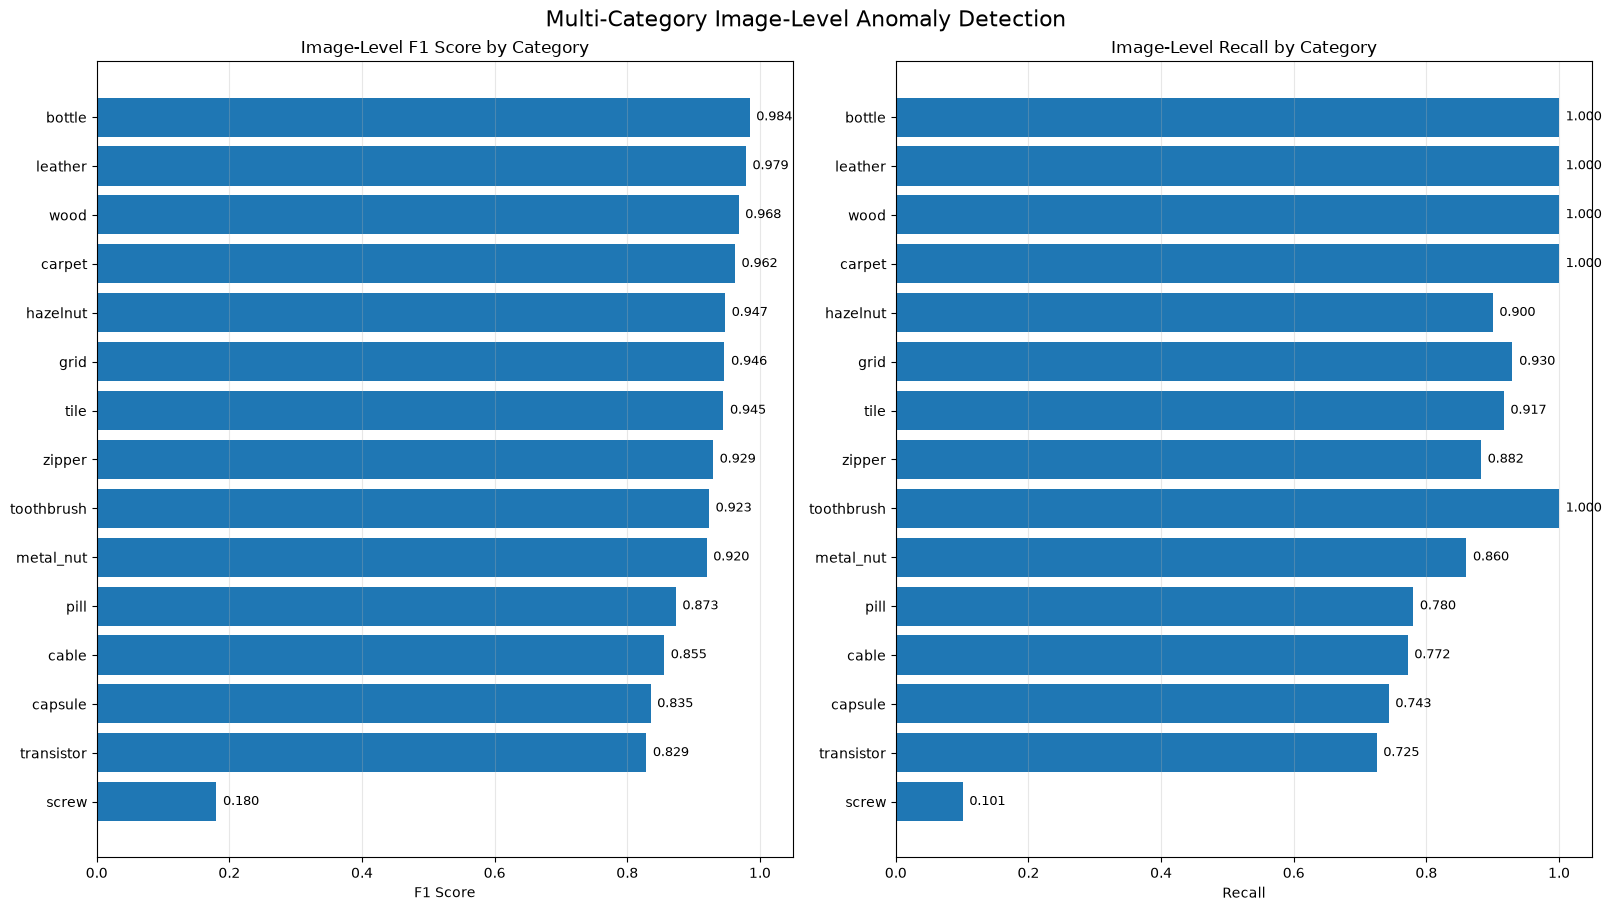

Clean image-level plot saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\multicategory_image_performance_clean.png


In [51]:
import matplotlib.pyplot as plt

image_plot_df = multicategory_combined_metrics_df[
    [
        "category",
        "roc_auc",
        "average_precision",
        "recall",
        "f1_score",
    ]
].copy()

image_plot_df = image_plot_df.sort_values(
    "f1_score",
    ascending=True,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 9),
    constrained_layout=True,
)

axes[0].barh(
    image_plot_df["category"],
    image_plot_df["f1_score"],
)
axes[0].set_title("Image-Level F1 Score by Category")
axes[0].set_xlabel("F1 Score")
axes[0].set_xlim(0, 1.05)
axes[0].grid(axis="x", alpha=0.3)

for index, value in enumerate(image_plot_df["f1_score"]):
    axes[0].text(
        value + 0.01,
        index,
        f"{value:.3f}",
        va="center",
        fontsize=9,
    )

axes[1].barh(
    image_plot_df["category"],
    image_plot_df["recall"],
)
axes[1].set_title("Image-Level Recall by Category")
axes[1].set_xlabel("Recall")
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis="x", alpha=0.3)

for index, value in enumerate(image_plot_df["recall"]):
    axes[1].text(
        value + 0.01,
        index,
        f"{value:.3f}",
        va="center",
        fontsize=9,
    )

fig.suptitle(
    "Multi-Category Image-Level Anomaly Detection",
    fontsize=16,
)

image_comparison_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "multicategory_image_performance_clean.png"
)

plt.savefig(
    image_comparison_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Clean image-level plot saved to:")
print(image_comparison_path)

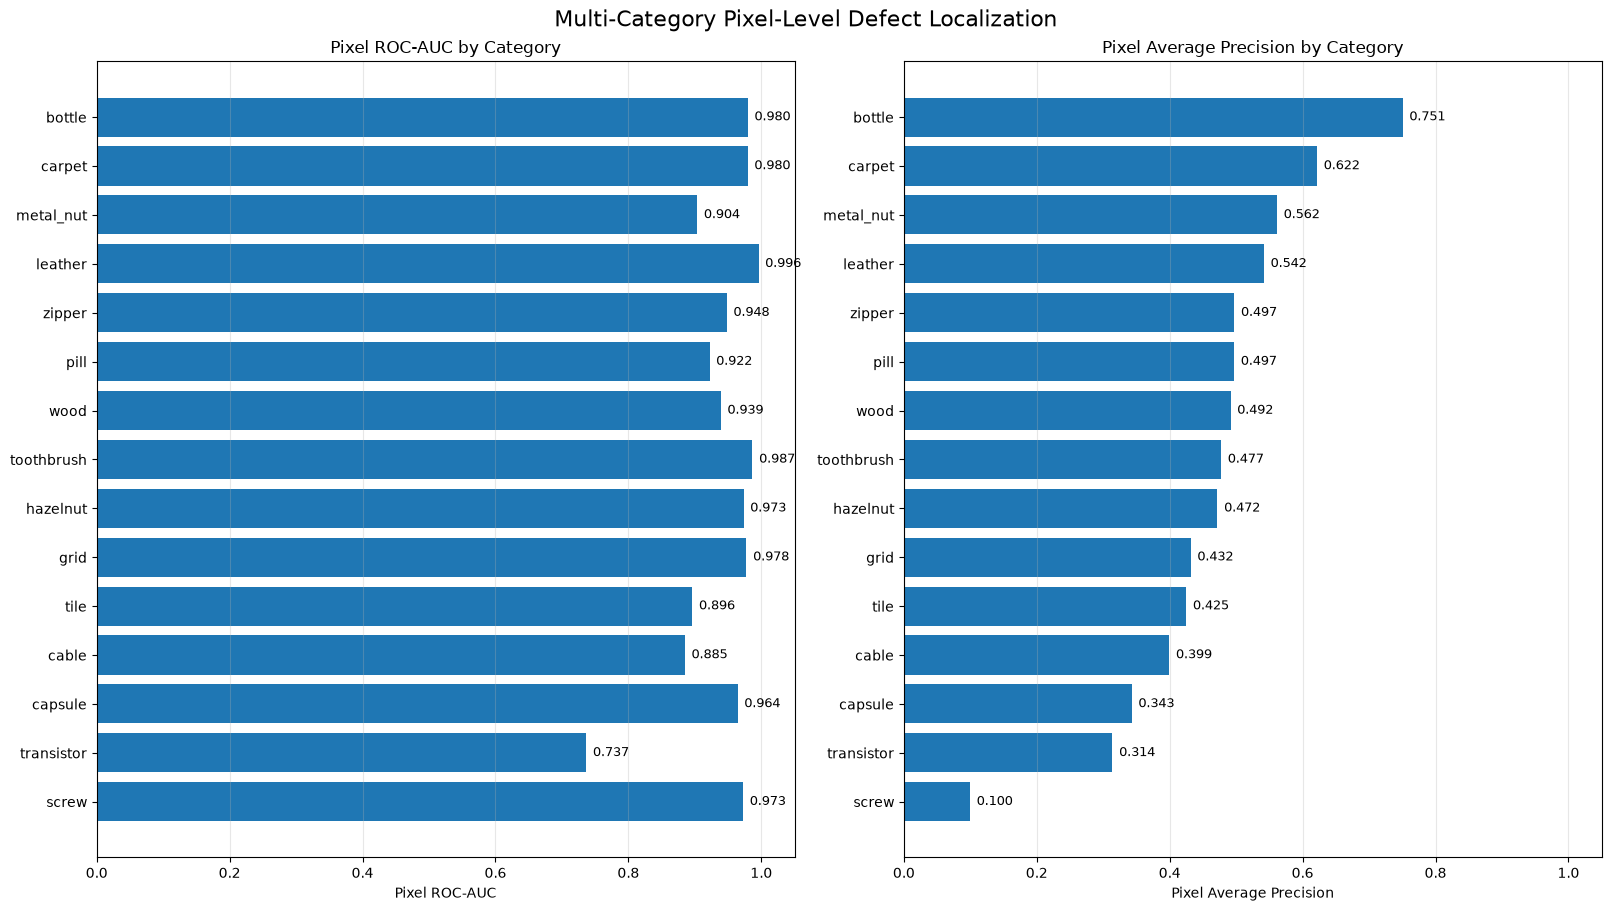

Clean pixel-level plot saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\multicategory_pixel_performance_clean.png


In [52]:
pixel_plot_df = multicategory_combined_metrics_df[
    [
        "category",
        "pixel_roc_auc",
        "pixel_average_precision",
    ]
].copy()

pixel_plot_df = pixel_plot_df.sort_values(
    "pixel_average_precision",
    ascending=True,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 9),
    constrained_layout=True,
)

axes[0].barh(
    pixel_plot_df["category"],
    pixel_plot_df["pixel_roc_auc"],
)
axes[0].set_title("Pixel ROC-AUC by Category")
axes[0].set_xlabel("Pixel ROC-AUC")
axes[0].set_xlim(0, 1.05)
axes[0].grid(axis="x", alpha=0.3)

for index, value in enumerate(pixel_plot_df["pixel_roc_auc"]):
    axes[0].text(
        value + 0.01,
        index,
        f"{value:.3f}",
        va="center",
        fontsize=9,
    )

axes[1].barh(
    pixel_plot_df["category"],
    pixel_plot_df["pixel_average_precision"],
)
axes[1].set_title("Pixel Average Precision by Category")
axes[1].set_xlabel("Pixel Average Precision")
axes[1].set_xlim(0, 1.05)
axes[1].grid(axis="x", alpha=0.3)

for index, value in enumerate(pixel_plot_df["pixel_average_precision"]):
    axes[1].text(
        value + 0.01,
        index,
        f"{value:.3f}",
        va="center",
        fontsize=9,
    )

fig.suptitle(
    "Multi-Category Pixel-Level Defect Localization",
    fontsize=16,
)

pixel_comparison_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "multicategory_pixel_performance_clean.png"
)

plt.savefig(
    pixel_comparison_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Clean pixel-level plot saved to:")
print(pixel_comparison_path)

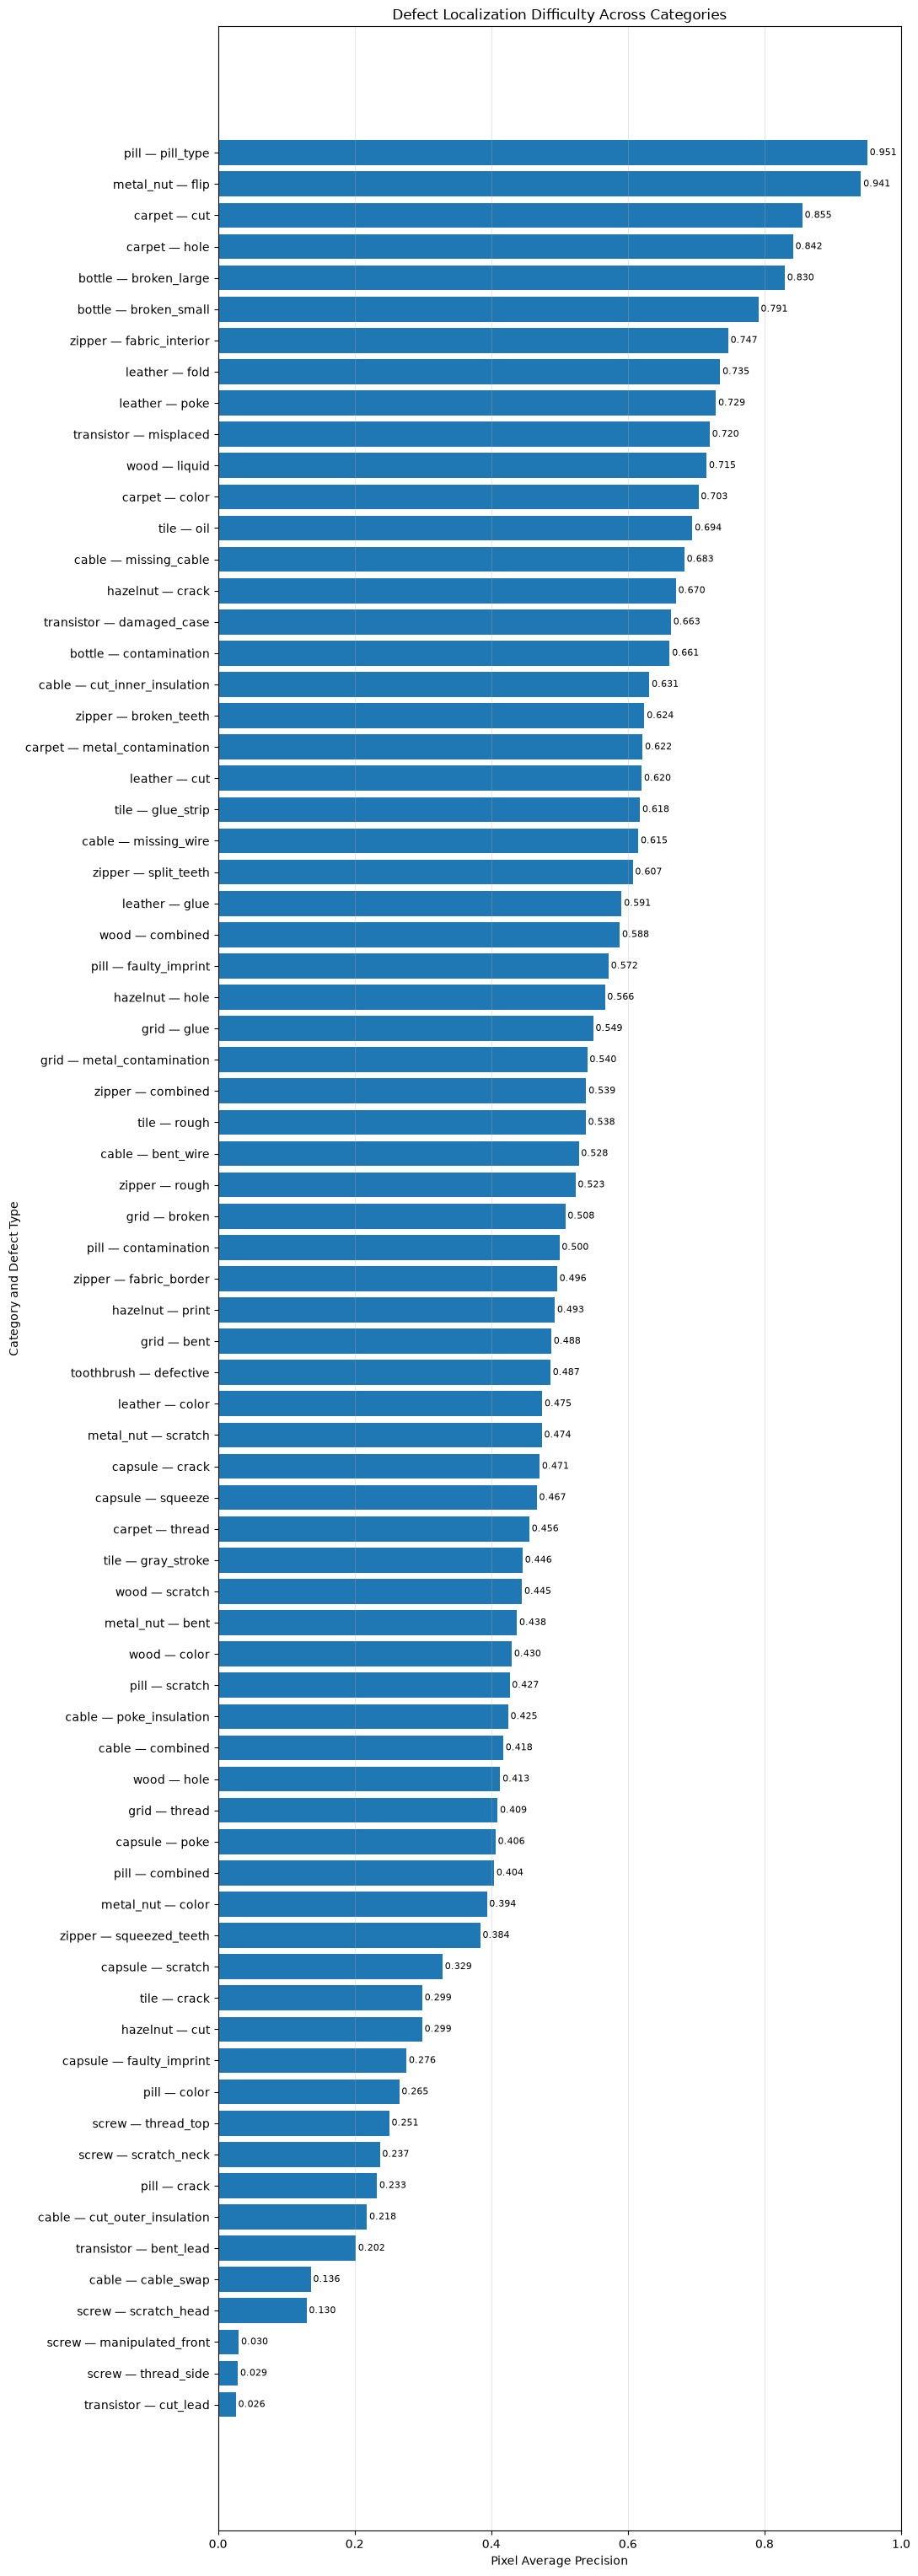

Per-defect comparison saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\multicategory_per_defect_pixel_ap.png


In [30]:
sorted_defect_metrics_df = (
    multicategory_per_defect_pixel_df
    .sort_values(
        "pixel_average_precision",
        ascending=True,
    )
    .copy()
)

sorted_defect_metrics_df["display_name"] = (
    sorted_defect_metrics_df["category"]
    + " — "
    + sorted_defect_metrics_df["defect_type"]
)

plt.figure(
    figsize=(
        11,
        max(
            7,
            len(sorted_defect_metrics_df) * 0.42,
        ),
    )
)

plt.barh(
    sorted_defect_metrics_df["display_name"],
    sorted_defect_metrics_df[
        "pixel_average_precision"
    ],
)

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.3f",
        label_type="edge",
        fontsize=8,
        padding=2,
    )
    
plt.xlabel("Pixel Average Precision")
plt.ylabel("Category and Defect Type")
plt.title(
    "Defect Localization Difficulty Across Categories"
)
plt.xlim(0, 1)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

per_defect_figure_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "multicategory_per_defect_pixel_ap.png"
)

plt.savefig(
    per_defect_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Per-defect comparison saved to:\n"
    f"{per_defect_figure_path}"
)

In [31]:
combined_metrics_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "multicategory_combined_metrics.csv"
)

multicategory_combined_metrics_df.to_csv(
    combined_metrics_path,
    index=False,
)

print(
    "Combined multi-category metrics saved to:\n"
    f"{combined_metrics_path}"
)

Combined multi-category metrics saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\multicategory_combined_metrics.csv


## Save detector configuration files for all categories

Each MVTec category requires its own normal memory bank and thresholds. The following cells calculate pixel thresholds from normal validation images and save one configuration file per category so the Streamlit app can load category-specific detectors.


In [32]:
PIXEL_THRESHOLD_PERCENTILE = 99.5

category_pixel_thresholds = {}
category_pixel_threshold_records = []

for category in CATEGORIES:
    print("=" * 70)
    print(f"PIXEL THRESHOLD: {category}")
    print("=" * 70)

    normalized_memory_bank = F.normalize(
        category_memory_banks[category].float(),
        p=2,
        dim=1,
    )

    gpu_memory_bank = normalized_memory_bank.to(
        DEVICE,
        non_blocking=True,
    )

    validation_pixel_results = collect_category_pixel_results(
        feature_extractor=feature_extractor,
        data_loader=category_data[category]["validation_loader"],
        memory_bank=gpu_memory_bank,
        device=DEVICE,
        category=category,
    )

    validation_maps = validation_pixel_results["anomaly_maps"]
    flattened_validation_pixels = validation_maps.reshape(-1)

    pixel_threshold = np.percentile(
        flattened_validation_pixels,
        PIXEL_THRESHOLD_PERCENTILE,
    )

    normal_pixels_above_threshold = (
        flattened_validation_pixels > pixel_threshold
    ).mean()

    category_pixel_thresholds[category] = float(pixel_threshold)

    category_pixel_threshold_records.append(
        {
            "category": category,
            "pixel_threshold_percentile": PIXEL_THRESHOLD_PERCENTILE,
            "pixel_threshold": float(pixel_threshold),
            "normal_pixel_false_positive_rate": float(
                normal_pixels_above_threshold
            ),
        }
    )

    print(f"Pixel threshold: {pixel_threshold:.6f}")
    print(
        "Normal pixel false-positive rate:",
        f"{normal_pixels_above_threshold:.4%}",
    )

    del gpu_memory_bank

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print()


PIXEL THRESHOLD: bottle


Pixel threshold: 0.615334
Normal pixel false-positive rate: 0.5000%

PIXEL THRESHOLD: cable


Pixel threshold: 0.751858
Normal pixel false-positive rate: 0.5000%

PIXEL THRESHOLD: capsule


Pixel threshold: 0.577299
Normal pixel false-positive rate: 0.5000%

PIXEL THRESHOLD: carpet


Pixel threshold: 0.590775
Normal pixel false-positive rate: 0.5000%

PIXEL THRESHOLD: grid


...

Pixel threshold: 0.723773
Normal pixel false-positive rate: 0.5000%

PIXEL THRESHOLD: toothbrush


Pixel threshold: 0.686616
Normal pixel false-positive rate: 0.5001%

PIXEL THRESHOLD: transistor


Pixel threshold: 0.706466
Normal pixel false-positive rate: 0.5000%

PIXEL THRESHOLD: wood


Pixel threshold: 0.681198
Normal pixel false-positive rate: 0.5000%

PIXEL THRESHOLD: zipper


Pixel threshold: 0.516759
Normal pixel false-positive rate: 0.5000%



In [33]:
category_pixel_thresholds_df = pd.DataFrame(
    category_pixel_threshold_records
)

display_category_pixel_thresholds_df = (
    category_pixel_thresholds_df.copy()
)

display_category_pixel_thresholds_df[
    [
        "pixel_threshold",
        "normal_pixel_false_positive_rate",
    ]
] = display_category_pixel_thresholds_df[
    [
        "pixel_threshold",
        "normal_pixel_false_positive_rate",
    ]
].round(6)

display_category_pixel_thresholds_df


,category,pixel_threshold_percentile,pixel_threshold,normal_pixel_false_positive_rate
0,bottle,99.5,0.615334,0.005000
1,cable,99.5,0.751858,0.005000
2,capsule,99.5,0.577299,0.005000
3,carpet,99.5,0.590775,0.005000
4,grid,99.5,0.550668,0.005000
5,hazelnut,99.5,0.780364,0.005000
6,leather,99.5,0.531457,0.005000
7,metal_nut,99.5,0.764012,0.005000
8,pill,99.5,0.696446,0.005000
9,screw,99.5,0.724282,0.005000


In [34]:
category_pixel_thresholds_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "all_category_pixel_thresholds.csv"
)

category_pixel_thresholds_df.to_csv(
    category_pixel_thresholds_path,
    index=False,
)

print("All category pixel thresholds saved to:")
print(category_pixel_thresholds_path)


All category pixel thresholds saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\all_category_pixel_thresholds.csv


In [35]:
import json

POSTPROCESSING_CONFIG = {
    "enabled": True,
    "minimum_component_area": 64,
    "opening_kernel_size": 3,
    "closing_kernel_size": 5,
}

all_category_config_records = []

for category in CATEGORIES:
    category_image_metrics = (
        multicategory_image_metrics_df[
            multicategory_image_metrics_df["category"] == category
        ]
        .iloc[0]
    )

    category_pixel_metrics = (
        multicategory_pixel_metrics_df[
            multicategory_pixel_metrics_df["category"] == category
        ]
        .iloc[0]
    )

    detector_configuration = {
        "category": category,
        "backbone": "ResNet-18",
        "feature_layer": "layer2",
        "image_size": IMAGE_SIZE,
        "feature_map_size": [32, 32],
        "feature_dimensions": 128,
        "memory_bank_size": int(
            len(category_memory_banks[category])
        ),
        "image_score_method": "feature_top_1_percent",
        "image_score_threshold": float(
            category_thresholds[category]
        ),
        "pixel_threshold": float(
            category_pixel_thresholds[category]
        ),
        "pixel_threshold_percentile": float(
            PIXEL_THRESHOLD_PERCENTILE
        ),
        "postprocessing": POSTPROCESSING_CONFIG,
        "final_image_metrics": {
            "roc_auc": float(category_image_metrics["roc_auc"]),
            "average_precision": float(
                category_image_metrics["average_precision"]
            ),
            "accuracy": float(category_image_metrics["accuracy"]),
            "precision": float(category_image_metrics["precision"]),
            "recall": float(category_image_metrics["recall"]),
            "f1_score": float(category_image_metrics["f1_score"]),
        },
        "final_pixel_metrics": {
            "pixel_roc_auc": float(
                category_pixel_metrics["pixel_roc_auc"]
            ),
            "pixel_average_precision": float(
                category_pixel_metrics["pixel_average_precision"]
            ),
            "defective_pixel_fraction": float(
                category_pixel_metrics["defective_pixel_fraction"]
            ),
        },
    }

    configuration_path = (
        PROJECT_ROOT
        / "models"
        / f"feature_detector_{category}_config.json"
    )

    with configuration_path.open(
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(
            detector_configuration,
            output_file,
            indent=4,
        )

    all_category_config_records.append(
        {
            "category": category,
            "memory_bank_path": str(
                PROJECT_ROOT
                / "models"
                / f"resnet18_memory_bank_{category}.pt"
            ),
            "configuration_path": str(configuration_path),
            "image_threshold": float(
                category_thresholds[category]
            ),
            "pixel_threshold": float(
                category_pixel_thresholds[category]
            ),
        }
    )

    print(f"Saved config for {category}:")
    print(configuration_path)


Saved config for bottle:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_bottle_config.json
Saved config for cable:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_cable_config.json
Saved config for capsule:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_capsule_config.json
Saved config for carpet:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_carpet_config.json
Saved config for grid:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_grid_config.json
Saved config for hazelnut:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_hazelnut_config.json
Saved config for leather:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_leather_config.json
Saved config for metal_nut:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_metal_nut_config.json
Saved config for pill:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_pill_config.json
Saved config for screw:
D:\PROJECTS\ANOMALY DETECTION\models\feature_detector_screw_config.json
Saved config for t

In [36]:
all_category_config_df = pd.DataFrame(
    all_category_config_records
)

all_category_config_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "all_category_detector_configs.csv"
)

all_category_config_df.to_csv(
    all_category_config_path,
    index=False,
)

print("All category detector configuration table saved to:")
print(all_category_config_path)

all_category_config_df


All category detector configuration table saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\all_category_detector_configs.csv


,category,memory_bank_path,configuration_path,image_threshold,pixel_threshold
0,bottle,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.719023,0.615334
1,cable,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.815643,0.751858
2,capsule,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.689591,0.577299
3,carpet,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.652125,0.590775
4,grid,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.620898,0.550668
5,hazelnut,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.842296,0.780364
6,leather,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.597061,0.531457
7,metal_nut,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.822107,0.764012
8,pill,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.774266,0.696446
9,screw,D:\PROJECTS\ANOMALY DETECTION\models\resnet18_...,D:\PROJECTS\ANOMALY DETECTION\models\feature_d...,0.812309,0.724282


In [37]:
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


def apply_robustness_transform(
    images: torch.Tensor,
    transform_name: str,
) -> torch.Tensor:
    """Apply a robustness perturbation to a batch of images.

    Images are expected to be tensors in the range [0, 1]
    with shape [B, 3, H, W].
    """

    if transform_name == "clean":
        return images

    if transform_name == "brightness_down":
        return torch.clamp(images * 0.75, 0.0, 1.0)

    if transform_name == "brightness_up":
        return torch.clamp(images * 1.25, 0.0, 1.0)

    if transform_name == "contrast_down":
        image_mean = images.mean(
            dim=(2, 3),
            keepdim=True,
        )

        return torch.clamp(
            (images - image_mean) * 0.75 + image_mean,
            0.0,
            1.0,
        )

    if transform_name == "gaussian_noise":
        noise = torch.randn_like(images) * 0.05

        return torch.clamp(
            images + noise,
            0.0,
            1.0,
        )

    if transform_name == "gaussian_blur":
        blurred_images = []

        for image in images:
            blurred_images.append(
                TF.gaussian_blur(
                    image,
                    kernel_size=[7, 7],
                    sigma=[1.5, 1.5],
                )
            )

        return torch.stack(blurred_images)

    if transform_name == "rotation_5_degrees":
        rotated_images = []

        for image in images:
            rotated_images.append(
                TF.rotate(
                    image,
                    angle=5,
                    interpolation=InterpolationMode.BILINEAR,
                    fill=1.0,
                )
            )

        return torch.stack(rotated_images)

    raise ValueError(
        f"Unknown transform name: {transform_name}"
    )

In [38]:
ROBUSTNESS_TRANSFORMS = [
    "clean",
    "brightness_down",
    "brightness_up",
    "contrast_down",
    "gaussian_noise",
    "gaussian_blur",
    "rotation_5_degrees",
]

print("Robustness transforms:")

for transform_name in ROBUSTNESS_TRANSFORMS:
    print(transform_name)

Robustness transforms:
clean
brightness_down
brightness_up
contrast_down
gaussian_noise
gaussian_blur
rotation_5_degrees


In [39]:
ROBUSTNESS_CATEGORIES = [
    "bottle",
    "cable",
    "carpet",
]

print("Robustness evaluation categories:")

for category in ROBUSTNESS_CATEGORIES:
    print("-", category)


Robustness evaluation categories:
- bottle
- cable
- carpet


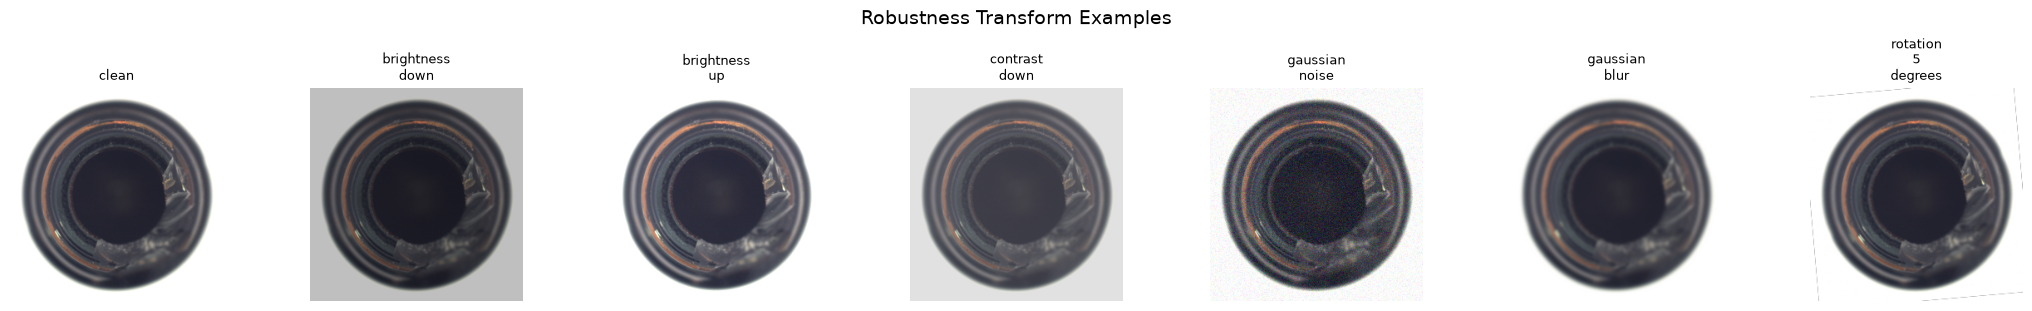

Robustness examples saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\robustness_transform_examples.png


In [40]:
sample = category_data["bottle"]["test_dataset"][0]

sample_image = sample["image"].unsqueeze(0).to(DEVICE)

transformed_images = []

for transform_name in ROBUSTNESS_TRANSFORMS:
    transformed = apply_robustness_transform(
        sample_image,
        transform_name,
    )

    transformed_images.append(
        transformed.squeeze(0).cpu()
    )

figure, axes = plt.subplots(
    1,
    len(ROBUSTNESS_TRANSFORMS),
    figsize=(3 * len(ROBUSTNESS_TRANSFORMS), 3),
    constrained_layout=True,
)

for axis, transform_name, image_tensor in zip(
    axes,
    ROBUSTNESS_TRANSFORMS,
    transformed_images,
):
    image_array = (
        image_tensor
        .permute(1, 2, 0)
        .numpy()
    )

    axis.imshow(
        np.clip(image_array, 0, 1)
    )

    axis.set_title(
        transform_name.replace("_", "\n"),
        fontsize=9,
    )

    axis.axis("off")

plt.suptitle(
    "Robustness Transform Examples",
    fontsize=14,
)

robustness_examples_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "robustness_transform_examples.png"
)

plt.savefig(
    robustness_examples_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Robustness examples saved to:\n"
    f"{robustness_examples_path}"
)

In [41]:
def collect_robustness_scores(
    feature_extractor: torch.nn.Module,
    data_loader: DataLoader,
    memory_bank: torch.Tensor,
    device: torch.device,
    category: str,
    transform_name: str,
) -> tuple[pd.DataFrame, float]:
    """Calculate anomaly scores after applying one perturbation."""

    feature_extractor.eval()

    records = []
    processed_images = 0

    synchronize_device(device)
    start_time = time.perf_counter()

    with torch.inference_mode():
        for batch in tqdm(
            data_loader,
            desc=f"{category} | {transform_name}",
        ):
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            transformed_images = apply_robustness_transform(
                images,
                transform_name,
            )

            low_resolution_maps, _ = (
                generate_feature_anomaly_maps(
                    feature_extractor=feature_extractor,
                    images=transformed_images,
                    memory_bank=memory_bank,
                )
            )

            flattened_maps = low_resolution_maps.flatten(
                start_dim=1
            )

            top_k_count = max(
                1,
                int(flattened_maps.shape[1] * 0.01),
            )

            anomaly_scores = torch.topk(
                flattened_maps,
                k=top_k_count,
                dim=1,
            ).values.mean(dim=1)

            for batch_index in range(images.size(0)):
                records.append(
                    {
                        "category": category,
                        "transform": transform_name,
                        "image_path": batch["image_path"][batch_index],
                        "defect_type": batch["defect_type"][batch_index],
                        "label": int(batch["label"][batch_index].item()),
                        "anomaly_score": float(
                            anomaly_scores[batch_index].item()
                        ),
                    }
                )

            processed_images += images.size(0)

    synchronize_device(device)

    elapsed_time = time.perf_counter() - start_time
    seconds_per_image = elapsed_time / processed_images

    return pd.DataFrame(records), seconds_per_image

In [42]:
robustness_records = []
robustness_score_tables = []

for category in ROBUSTNESS_CATEGORIES:
    print(f"ROBUSTNESS CATEGORY: {category}")
    
    normalized_memory_bank = F.normalize(
        category_memory_banks[category].float(),
        p=2,
        dim=1,
    )

    gpu_memory_bank = normalized_memory_bank.to(
        DEVICE,
        non_blocking=True,
    )

    threshold = category_thresholds[category]

    for transform_name in ROBUSTNESS_TRANSFORMS:
        scores_df, seconds_per_image = collect_robustness_scores(
            feature_extractor=feature_extractor,
            data_loader=category_data[category]["test_loader"],
            memory_bank=gpu_memory_bank,
            device=DEVICE,
            category=category,
            transform_name=transform_name,
        )

        true_labels = scores_df["label"].to_numpy()
        anomaly_scores = scores_df["anomaly_score"].to_numpy()

        predicted_labels = (
            anomaly_scores > threshold
        ).astype(np.uint8)

        tn, fp, fn, tp = confusion_matrix(
            true_labels,
            predicted_labels,
            labels=[0, 1],
        ).ravel()

        robustness_records.append(
            {
                "category": category,
                "transform": transform_name,
                "threshold": threshold,
                "roc_auc": roc_auc_score(
                    true_labels,
                    anomaly_scores,
                ),
                "average_precision": average_precision_score(
                    true_labels,
                    anomaly_scores,
                ),
                "accuracy": accuracy_score(
                    true_labels,
                    predicted_labels,
                ),
                "precision": precision_score(
                    true_labels,
                    predicted_labels,
                    zero_division=0,
                ),
                "recall": recall_score(
                    true_labels,
                    predicted_labels,
                    zero_division=0,
                ),
                "f1_score": f1_score(
                    true_labels,
                    predicted_labels,
                    zero_division=0,
                ),
                "true_negative": int(tn),
                "false_positive": int(fp),
                "false_negative": int(fn),
                "true_positive": int(tp),
                "seconds_per_image": seconds_per_image,
            }
        )

        robustness_score_tables.append(scores_df)

        print(
            f"{transform_name:<20} "
            f"| ROC-AUC: {robustness_records[-1]['roc_auc']:.4f} "
            f"| Recall: {robustness_records[-1]['recall']:.4f} "
            f"| F1: {robustness_records[-1]['f1_score']:.4f}"
        )

    del gpu_memory_bank

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print()

ROBUSTNESS CATEGORY: bottle


bottle | clean: 100%|██████████| 11/11 [00:03<00:00,  3.34it/s]


clean                | ROC-AUC: 0.9992 | Recall: 1.0000 | F1: 0.9844


bottle | brightness_down: 100%|██████████| 11/11 [00:03<00:00,  3.27it/s]


brightness_down      | ROC-AUC: 0.9992 | Recall: 1.0000 | F1: 0.9921


...

gaussian_noise       | ROC-AUC: 0.9406 | Recall: 1.0000 | F1: 0.8641


carpet | gaussian_blur: 100%|██████████| 15/15 [00:07<00:00,  2.11it/s]


gaussian_blur        | ROC-AUC: 0.9880 | Recall: 1.0000 | F1: 0.8641


carpet | rotation_5_degrees: 100%|██████████| 15/15 [00:07<00:00,  2.07it/s]

rotation_5_degrees   | ROC-AUC: 0.5783 | Recall: 1.0000 | F1: 0.8641



In [43]:
robustness_metrics_df = pd.DataFrame(
    robustness_records
)

display_robustness_df = robustness_metrics_df.copy()

columns_to_round = [
    "threshold",
    "roc_auc",
    "average_precision",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "seconds_per_image",
]

display_robustness_df[columns_to_round] = (
    display_robustness_df[columns_to_round].round(4)
)

display_robustness_df[
    [
        "category",
        "transform",
        "roc_auc",
        "average_precision",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "false_positive",
        "false_negative",
    ]
]

,category,transform,roc_auc,average_precision,accuracy,precision,recall,f1_score,false_positive,false_negative
0,bottle,clean,0.9992,0.9998,0.9759,0.9692,1.0000,0.9844,2,0
1,bottle,brightness_down,0.9992,0.9998,0.9880,0.9844,1.0000,0.9921,1,0
2,bottle,brightness_up,1.0000,1.0000,0.9639,0.9545,1.0000,0.9767,3,0
3,bottle,contrast_down,0.9992,0.9998,0.9880,0.9844,1.0000,0.9921,1,0
4,bottle,gaussian_noise,0.9865,0.9959,0.7590,0.7590,1.0000,0.8630,20,0
5,bottle,gaussian_blur,0.9992,0.9998,0.9639,0.9545,1.0000,0.9767,3,0
6,bottle,rotation_5_degrees,0.9579,0.9892,0.7590,0.7590,1.0000,0.8630,20,0
7,cable,clean,0.9314,0.9626,0.8400,0.9595,0.7717,0.8554,3,21
8,cable,brightness_down,0.9284,0.9619,0.8333,0.9589,0.7609,0.8485,3,22
9,cable,brightness_up,0.9335,0.9641,0.8800,0.9111,0.8913,0.9011,8,10


In [44]:
clean_metrics_df = (
    robustness_metrics_df[
        robustness_metrics_df["transform"] == "clean"
    ][
        [
            "category",
            "roc_auc",
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "false_positive",
            "false_negative",
        ]
    ]
    .rename(
        columns={
            "roc_auc": "clean_roc_auc",
            "accuracy": "clean_accuracy",
            "precision": "clean_precision",
            "recall": "clean_recall",
            "f1_score": "clean_f1_score",
            "false_positive": "clean_false_positive",
            "false_negative": "clean_false_negative",
        }
    )
)

robustness_degradation_df = (
    robustness_metrics_df
    .merge(
        clean_metrics_df,
        on="category",
        how="left",
    )
)

robustness_degradation_df["roc_auc_change"] = (
    robustness_degradation_df["roc_auc"]
    - robustness_degradation_df["clean_roc_auc"]
)

robustness_degradation_df["accuracy_change"] = (
    robustness_degradation_df["accuracy"]
    - robustness_degradation_df["clean_accuracy"]
)

robustness_degradation_df["precision_change"] = (
    robustness_degradation_df["precision"]
    - robustness_degradation_df["clean_precision"]
)

robustness_degradation_df["recall_change"] = (
    robustness_degradation_df["recall"]
    - robustness_degradation_df["clean_recall"]
)

robustness_degradation_df["f1_change"] = (
    robustness_degradation_df["f1_score"]
    - robustness_degradation_df["clean_f1_score"]
)

robustness_degradation_df["false_positive_change"] = (
    robustness_degradation_df["false_positive"]
    - robustness_degradation_df["clean_false_positive"]
)

robustness_degradation_df["false_negative_change"] = (
    robustness_degradation_df["false_negative"]
    - robustness_degradation_df["clean_false_negative"]
)

display_robustness_degradation_df = (
    robustness_degradation_df[
        [
            "category",
            "transform",
            "roc_auc_change",
            "accuracy_change",
            "precision_change",
            "recall_change",
            "f1_change",
            "false_positive_change",
            "false_negative_change",
        ]
    ]
    .copy()
)

display_robustness_degradation_df[
    [
        "roc_auc_change",
        "accuracy_change",
        "precision_change",
        "recall_change",
        "f1_change",
    ]
] = display_robustness_degradation_df[
    [
        "roc_auc_change",
        "accuracy_change",
        "precision_change",
        "recall_change",
        "f1_change",
    ]
].round(4)

display_robustness_degradation_df

,category,transform,roc_auc_change,accuracy_change,precision_change,recall_change,f1_change,false_positive_change,false_negative_change
0,bottle,clean,0.0000,0.0000,0.0000,0.0000,0.0000,0,0
1,bottle,brightness_down,0.0000,0.0120,0.0151,0.0000,0.0078,-1,0
2,bottle,brightness_up,0.0008,-0.0120,-0.0147,0.0000,-0.0076,1,0
3,bottle,contrast_down,0.0000,0.0120,0.0151,0.0000,0.0078,-1,0
4,bottle,gaussian_noise,-0.0127,-0.2169,-0.2102,0.0000,-0.1214,18,0
5,bottle,gaussian_blur,0.0000,-0.0120,-0.0147,0.0000,-0.0076,1,0
6,bottle,rotation_5_degrees,-0.0413,-0.2169,-0.2102,0.0000,-0.1214,18,0
7,cable,clean,0.0000,0.0000,0.0000,0.0000,0.0000,0,0
8,cable,brightness_down,-0.0030,-0.0067,-0.0006,-0.0109,-0.0069,0,1
9,cable,brightness_up,0.0021,0.0400,-0.0483,0.1196,0.0457,5,-11


In [45]:
average_robustness_impact_df = (
    robustness_degradation_df
    .groupby("transform")
    .agg(
        mean_roc_auc=("roc_auc", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1_score=("f1_score", "mean"),
        mean_roc_auc_change=("roc_auc_change", "mean"),
        mean_f1_change=("f1_change", "mean"),
        total_false_positive=("false_positive", "sum"),
        total_false_negative=("false_negative", "sum"),
    )
    .reset_index()
)

display_average_robustness_impact_df = (
    average_robustness_impact_df.copy()
)

display_average_robustness_impact_df[
    [
        "mean_roc_auc",
        "mean_accuracy",
        "mean_precision",
        "mean_recall",
        "mean_f1_score",
        "mean_roc_auc_change",
        "mean_f1_change",
    ]
] = display_average_robustness_impact_df[
    [
        "mean_roc_auc",
        "mean_accuracy",
        "mean_precision",
        "mean_recall",
        "mean_f1_score",
        "mean_roc_auc_change",
        "mean_f1_change",
    ]
].round(4)

display_average_robustness_impact_df.sort_values(
    "mean_f1_score",
    ascending=False,
)

,transform,mean_roc_auc,mean_accuracy,mean_precision,mean_recall,mean_f1_score,mean_roc_auc_change,mean_f1_change,total_false_positive,total_false_negative
3,contrast_down,0.9750,0.9465,0.9781,0.9348,0.9541,-0.0019,0.0201,5,18
0,brightness_down,0.9755,0.9376,0.9774,0.9203,0.9450,-0.0014,0.0110,5,22
2,clean,0.9769,0.9187,0.9519,0.9239,0.9340,0.0000,0.0000,12,21
1,brightness_up,0.9761,0.8796,0.8844,0.9638,0.9197,-0.0008,-0.0143,35,10
4,gaussian_blur,0.9715,0.8660,0.8850,0.9493,0.9108,-0.0054,-0.0232,36,14
5,gaussian_noise,0.9271,0.7110,0.7110,1.0000,0.8291,-0.0498,-0.1048,106,0
6,rotation_5_degrees,0.7155,0.7110,0.7110,1.0000,0.8291,-0.2614,-0.1048,106,0


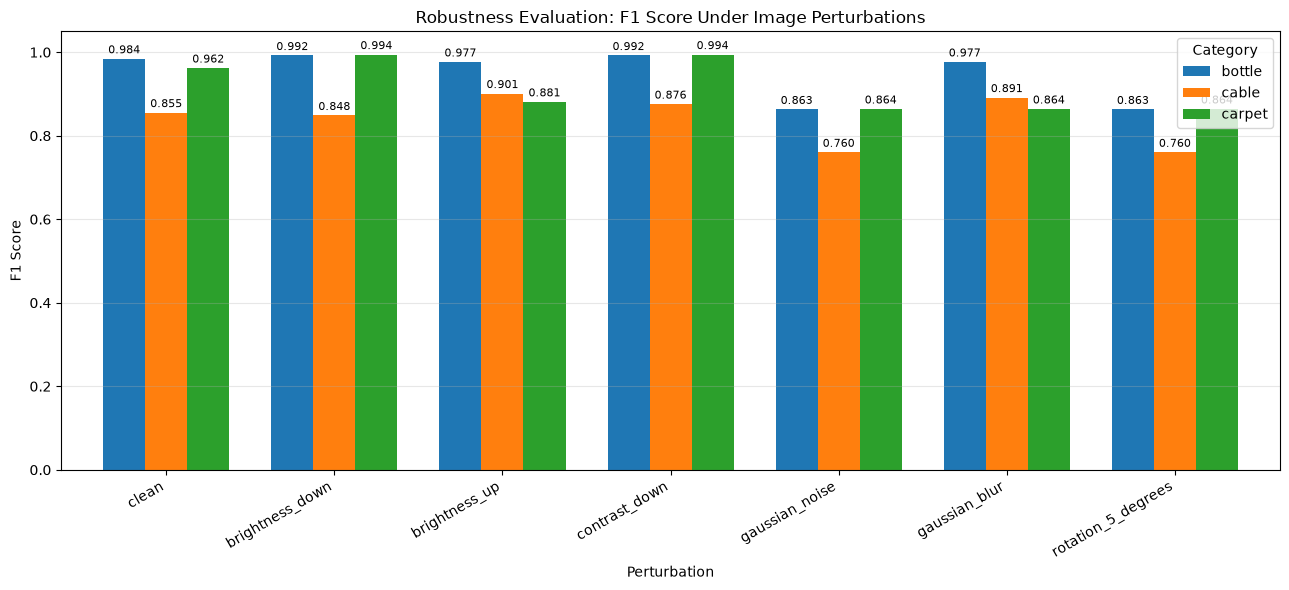

Robustness F1 figure saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\robustness_f1_by_category.png


In [46]:
robustness_f1_pivot = robustness_metrics_df.pivot(
    index="transform",
    columns="category",
    values="f1_score",
)

robustness_f1_pivot = robustness_f1_pivot.loc[
    ROBUSTNESS_TRANSFORMS
]

axis = robustness_f1_pivot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75,
)

axis.set_title(
    "Robustness Evaluation: F1 Score Under Image Perturbations"
)

axis.set_xlabel("Perturbation")
axis.set_ylabel("F1 Score")
axis.set_ylim(0, 1.05)
axis.grid(axis="y", alpha=0.3)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%.3f",
        label_type="edge",
        fontsize=8,
        padding=2,
    )

plt.xticks(rotation=30, ha="right")
plt.legend(title="Category")
plt.tight_layout()

robustness_f1_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "robustness_f1_by_category.png"
)

plt.savefig(
    robustness_f1_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Robustness F1 figure saved to:\n"
    f"{robustness_f1_path}"
)

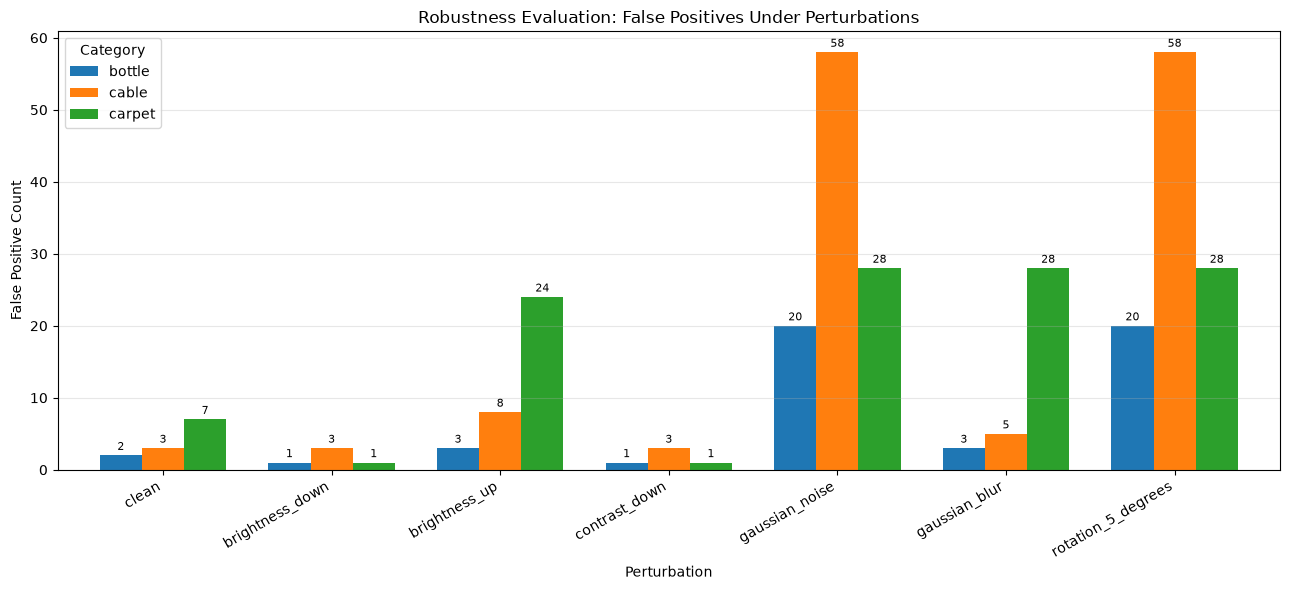

False-positive robustness figure saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\robustness_false_positives.png


In [47]:
false_positive_pivot = robustness_metrics_df.pivot(
    index="transform",
    columns="category",
    values="false_positive",
)

false_positive_pivot = false_positive_pivot.loc[
    ROBUSTNESS_TRANSFORMS
]

axis = false_positive_pivot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.75,
)

axis.set_title(
    "Robustness Evaluation: False Positives Under Perturbations"
)

axis.set_xlabel("Perturbation")
axis.set_ylabel("False Positive Count")
axis.grid(axis="y", alpha=0.3)

for container in axis.containers:
    axis.bar_label(
        container,
        fmt="%d",
        label_type="edge",
        fontsize=8,
        padding=2,
    )

plt.xticks(rotation=30, ha="right")
plt.legend(title="Category")
plt.tight_layout()

robustness_fp_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "robustness_false_positives.png"
)

plt.savefig(
    robustness_fp_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "False-positive robustness figure saved to:\n"
    f"{robustness_fp_path}"
)

In [48]:
robustness_metrics_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "robustness_image_metrics.csv"
)

robustness_degradation_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "robustness_degradation_metrics.csv"
)

average_robustness_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "robustness_average_impact.csv"
)

combined_robustness_scores_df = pd.concat(
    robustness_score_tables,
    ignore_index=True,
)

robustness_scores_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "robustness_image_scores.csv"
)

robustness_metrics_df.to_csv(
    robustness_metrics_path,
    index=False,
)

robustness_degradation_df.to_csv(
    robustness_degradation_path,
    index=False,
)

average_robustness_impact_df.to_csv(
    average_robustness_path,
    index=False,
)

combined_robustness_scores_df.to_csv(
    robustness_scores_path,
    index=False,
)

print("Robustness metrics saved to:")
print(robustness_metrics_path)

print("\nRobustness degradation saved to:")
print(robustness_degradation_path)

print("\nAverage robustness impact saved to:")
print(average_robustness_path)

print("\nRobustness scores saved to:")
print(robustness_scores_path)

Robustness metrics saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\robustness_image_metrics.csv

Robustness degradation saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\robustness_degradation_metrics.csv

Average robustness impact saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\robustness_average_impact.csv

Robustness scores saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\robustness_image_scores.csv


## Multi-category and robustness conclusions

The pretrained ResNet patch-feature detector is now evaluated across all 15 MVTec AD categories.

Main findings to record after running the notebook:

- The all-category tables show how performance varies across objects and textures.
- Each category has its own normal memory bank, image threshold, pixel threshold, and configuration file.
- Robustness testing is performed on representative categories only: bottle, cable, and carpet.
- Brightness and contrast changes usually have limited negative impact.
- Gaussian noise and small rotation can significantly increase false positives.
- The detector is therefore a strong unsupervised baseline, but robustness can be improved later using augmentation, alignment, or threshold calibration.


In [49]:
final_multicategory_summary = {
    "categories_evaluated": CATEGORIES,
    "number_of_categories": len(CATEGORIES),
    "robustness_categories_evaluated": ROBUSTNESS_CATEGORIES,
    "memory_bank_size_per_category": MEMORY_BANK_SIZE,
    "image_size": IMAGE_SIZE,
    "best_clean_category": (
        multicategory_combined_metrics_df
        .sort_values("f1_score", ascending=False)
        .iloc[0]["category"]
    ),
    "hardest_clean_category": (
        multicategory_combined_metrics_df
        .sort_values("f1_score", ascending=True)
        .iloc[0]["category"]
    ),
    "most_robust_transform_by_mean_f1": (
        average_robustness_impact_df
        .sort_values("mean_f1_score", ascending=False)
        .iloc[0]["transform"]
    ),
    "most_damaging_transform_by_mean_f1": (
        average_robustness_impact_df
        .sort_values("mean_f1_score", ascending=True)
        .iloc[0]["transform"]
    ),
}

final_multicategory_summary


{'categories_evaluated': ['bottle',
  'cable',
  'capsule',
  'carpet',
  'grid',
  'hazelnut',
  'leather',
  'metal_nut',
  'pill',
  'screw',
  'tile',
  'toothbrush',
  'transistor',
  'wood',
  'zipper'],
 'number_of_categories': 15,
 'robustness_categories_evaluated': ['bottle', 'cable', 'carpet'],
 'memory_bank_size_per_category': 10000,
 'image_size': 256,
 'best_clean_category': 'bottle',
 'hardest_clean_category': 'screw',
 'most_robust_transform_by_mean_f1': 'contrast_down',
 'most_damaging_transform_by_mean_f1': 'rotation_5_degrees'}

In [50]:
import json

summary_output_path = (
    PROJECT_ROOT
    / "results"
    / "metrics"
    / "multicategory_robustness_summary.json"
)

with summary_output_path.open("w", encoding="utf-8") as output_file:
    json.dump(
        final_multicategory_summary,
        output_file,
        indent=4,
    )

print("Multi-category robustness summary saved to:")
print(summary_output_path)

Multi-category robustness summary saved to:
D:\PROJECTS\ANOMALY DETECTION\results\metrics\multicategory_robustness_summary.json
